In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report 
df = pd.read_csv(r"C:\Users\chait\Downloads\archive (2)\tested.csv")
print("First 5 rows:")
print(df.head())
print("\nShape of dataset:")
print(df.shape)
print("\nAttributes:")
print(df.columns)
print("\nData types:")
print(df.dtypes)
print("\nSummary:")
print(df.describe(include="all"))
print("\ninformation")
print(df.info)






First 5 rows:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Shape of dataset:
(418, 12)

Attributes:
Index(['PassengerId', 'Survive

In [3]:
print("\nmissing values")
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("\n outliers")
for col in ["Age", "Fare"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
print("Outliers handled using IQR method.")


missing values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
0

 outliers
Outliers handled using IQR method.


In [4]:
cat_cols=df.select_dtypes(include=['object']).columns
print("categorical attributes:")
print(cat_cols)
df=pd.get_dummies(df,columns=["Sex", "Embarked"],drop_first=True)
print(df.head())

categorical attributes:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name   Age  SibSp  Parch   Ticket  \
0                              Kelly, Mr. James  34.5      0      0   330911   
1              Wilkes, Mrs. James (Ellen Needs)  47.0      1      0   363272   
2                     Myles, Mr. Thomas Francis  62.0      0      0   240276   
3                              Wirz, Mr. Albert  27.0      0      0   315154   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  22.0      1      1  3101298   

      Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0   7.8292   NaN      True        True       False  
1   7.0000   NaN     False       False        True  
2   9.6875   NaN      True        True       Fals

In [5]:
numerical_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]
print("Numerical attributes:")
print(numerical_columns)
# Handle missing Age
df["Age"] = df["Age"].fillna(df["Age"].median())
# Standardization
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)
print("\nScaled data:")
print(df[numerical_columns].head())

Numerical attributes:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Scaled data:
     Pclass       Age     SibSp     Parch      Fare
0  0.873482  0.390934 -0.499470 -0.400248 -0.794535
1  0.873482  1.382743  0.616992 -0.400248 -0.833638
2 -0.315819  2.572914 -0.499470 -0.400248 -0.706902
3  0.873482 -0.204151 -0.499470 -0.400248 -0.755238
4  0.873482 -0.600875  0.616992  0.619896 -0.584292


Correlation with Survived:
Survived       1.000000
Fare           0.203837
Parch          0.159120
SibSp          0.099943
Age            0.005721
PassengerId   -0.023245
Pclass        -0.108615
Name: Survived, dtype: float64


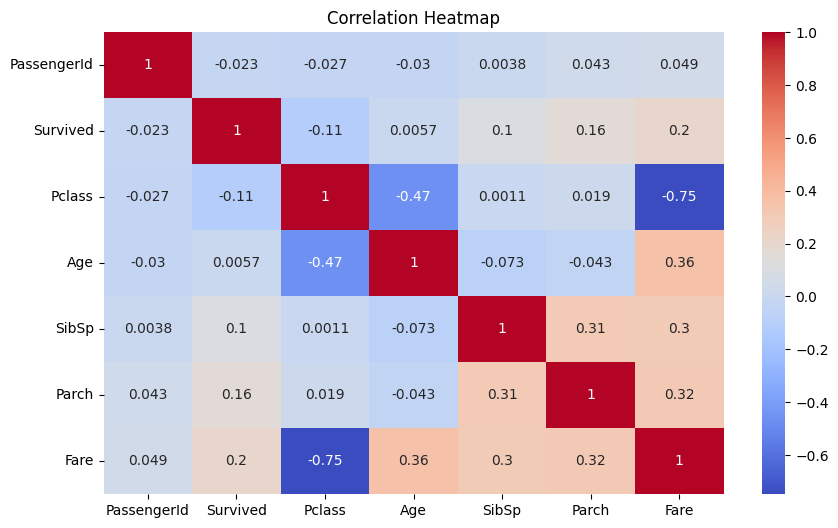


Survival rate by Pclass:
Pclass
-1.505120    0.467290
-0.315819    0.322581
 0.873482    0.330275
Name: Survived, dtype: float64


In [6]:
print("Correlation with Survived:")
print(
    df.select_dtypes(include="number")
      .corr()["Survived"]
      .sort_values(ascending=False)
)
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()
# Relationship between Pclass and Survival
print("\nSurvival rate by Pclass:")
print(df.groupby("Pclass")["Survived"].mean()
)



In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# Load dataset
df = pd.read_csv(r"C:\Users\chait\Downloads\archive (2)\tested.csv")
# Remove extra spaces from column names, if any
df.columns = df.columns.str.strip()
print("Columns:")
print(df.columns.tolist())
# Target
y = df["Survived"]
# BEFORE FEATURE SELECTION
features_before = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]
X_before = df[features_before]

print("\nFeatures before selection:")
print(X_before.columns.tolist())
# Numerical features
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]
# Categorical features
categorical_features = [
    "Sex",
    "Embarked"
]
# Preprocessing
preprocessor = ColumnTransformer([
    ("num",
     Pipeline([
         ("imputer", SimpleImputer(strategy="median")),
         ("scaler", StandardScaler())
     ]),
     numeric_features),

    ("cat",
     Pipeline([
         ("imputer", SimpleImputer(strategy="most_frequent")),
         ("encoder", OneHotEncoder(handle_unknown="ignore"))
     ]),
     categorical_features)
])
# Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_before,
    y,
    test_size=0.2,
    random_state=42
)
# Train
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)
# Accuracy
accuracy_before = accuracy_score(y_test, y_pred)
print("\nAccuracy BEFORE feature selection:",accuracy_before)
# AFTER FEATURE SELECTION
selected_features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare"
]
X_after = df[selected_features]
print("\nSelected features:")
print(X_after.columns.tolist())
# Numerical selected features
numeric_selected = [
    "Pclass",
    "Age",
    "Fare"
]
# Categorical selected features
categorical_selected = [
    "Sex"
]
preprocessor_selected = ColumnTransformer([
    ("num",
     Pipeline([
         ("imputer", SimpleImputer(strategy="median")),
         ("scaler", StandardScaler())
     ]),
     numeric_selected),

    ("cat",
     Pipeline([
         ("imputer", SimpleImputer(strategy="most_frequent")),
         ("encoder", OneHotEncoder(handle_unknown="ignore"))
     ]),
     categorical_selected)
])
# Model after feature selection
model_selected = Pipeline([
    ("preprocessor", preprocessor_selected),
    ("classifier", LogisticRegression(max_iter=1000))
])
# Split data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_after,y,test_size=0.2,random_state=42)
# Train
model_selected.fit(X_train2, y_train2)
# Predict
y_pred2 = model_selected.predict(X_test2)
# Accuracy
accuracy_after = accuracy_score(y_test2,y_pred2)
print("\nAccuracy AFTER feature selection:",accuracy_after)

# COMPARISON
print("\n--- Model Performance Comparison ---")
print("Before Feature Selection:", accuracy_before)
print("After Feature Selection:", accuracy_after)